#  Mental Health Data Analysis Project
##  Notebook 1: Data Cleaning and Exploratory Data Analysis (EDA)

In [2]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
%matplotlib inline

In [5]:
# Load dataset
df = pd.read_csv('Mental Health Dataset.csv')
df.head()

,Timestamp,Gender,Country,Occupation,self_employed,family_history,treatment,Days_Indoors,Growing_Stress,Changes_Habits,Mental_Health_History,Mood_Swings,Coping_Struggles,Work_Interest,Social_Weakness,mental_health_interview,care_options
0,2014-08-27 11:29:31,Female,United States,Corporate,NaN,No,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Not sure
1,2014-08-27 11:31:50,Female,United States,Corporate,NaN,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,No
2,2014-08-27 11:32:39,Female,United States,Corporate,NaN,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Yes
3,2014-08-27 11:37:59,Female,United States,Corporate,No,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,Maybe,Yes
4,2014-08-27 11:43:36,Female,United States,Corporate,No,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Yes


##  Step 1: Data Cleaning

In [10]:
# Convert Timestamp to datetime
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

# Normalize gender column
df['Gender'] = df['Gender'].str.lower().replace({
    'cis female': 'female',
    'cis male': 'male',
    'trans female': 'transgender',
    'trans male': 'transgender',
    'non-binary': 'non-binary',
    'male-ish': 'male',
    'female (trans)': 'transgender'
})

# Fill missing self_employed values with 'Unknown'
df['self_employed'] = df['self_employed'].fillna('Unknown')

# Encode mood_swing levels
mood_map = {'Low': 1, 'Medium': 2, 'High': 3}
df['Mood_Score'] = df['Mood_Swings'].map(mood_map)

###  Add new column: `Risk_Level`
To evaluate the severity of a person's condition, we will compute a new feature based on their self-reported mood swings, coping struggles, and mental health history.

**Add this column directly to the notebook, not the CSV.**

In [11]:
# Risk scoring: simple rule-based
def assess_risk(row):
    score = 0
    score += mood_map.get(row['Mood_Swings'], 0)
    score += 1 if row['Coping_Struggles'] == 'Yes' else 0
    score += 1 if row['Mental_Health_History'] == 'Yes' else 0
    if score >= 5:
        return 'High'
    elif score >= 3:
        return 'Medium'
    else:
        return 'Low'

df['Risk_Level'] = df.apply(assess_risk, axis=1)
df[['Mood_Score', 'Coping_Struggles', 'Mental_Health_History', 'Risk_Level']].head()

,Mood_Score,Coping_Struggles,Mental_Health_History,Risk_Level
0,2,No,Yes,Medium
1,2,No,Yes,Medium
2,2,No,Yes,Medium
3,2,No,Yes,Medium
4,2,No,Yes,Medium


##  Step 2: Exploratory Data Analysis

C:\Users\gnand\AppData\Local\Temp\ipykernel_17636\2315255399.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Risk_Level', palette='coolwarm')


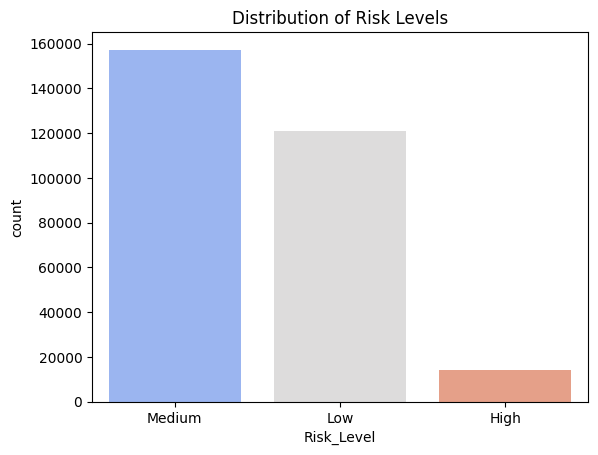

In [12]:
# Plot risk level distribution
sns.countplot(data=df, x='Risk_Level', palette='coolwarm')
plt.title('Distribution of Risk Levels')
plt.show()

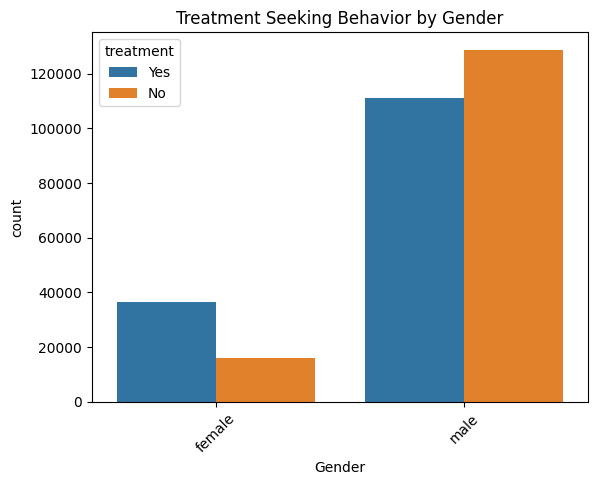

In [9]:
# Gender vs Treatment
sns.countplot(data=df, x='Gender', hue='treatment')
plt.title('Treatment Seeking Behavior by Gender')
plt.xticks(rotation=45)
plt.show()